# Practice 08 — Dataloader for Image

Tabular data went from a NumPy array straight into `TensorDataset`.
Images arrive as files on disk, in folders named after their class, and are usually altered at random
while training.

| Step | Dataset class | Where the data lives |
|:---|:---|:---|
| 1 | `TensorDataset` | RAM, standardized by hand |
| 2 | custom `Dataset` | RAM, standardized by a `transform` |
| 3 | `ImageFolder`, `datasets.CIFAR10` | disk, one image read per call |
| 4 | any of the three above | disk, a different random view per call |

**Dataset.** CIFAR-10: 32×32 colour photographs in 10 classes.

No model is trained here.

---
## Step 0. Imports and Setup

In [1]:
import os
import urllib.request
import zipfile

import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, TensorDataset
from PIL import Image
import matplotlib.pyplot as plt

np.random.seed(42)
torch.manual_seed(42)

plt.rcParams['axes.unicode_minus'] = False

print('torch      :', torch.__version__)
print('torchvision:', torchvision.__version__)

torch      : 2.6.0+cu124
torchvision: 0.21.0+cu124


---
## Step 1. NumPy Arrays — `TensorDataset`

CIFAR-10 ships as two fixed splits, 50000 train and 10000 test.
The test split is used here for monitoring only, so it is named `val`.
Of those, 200 and 50 images are kept — enough to watch the loaders work.

The tabular pipeline carries over: standardize, wrap in `TensorDataset`, hand to `DataLoader`.
Two things differ.

| | Tabular | Image |
|:---|:---|:---|
| Statistics | `axis=0`, one number per feature | `axis=(0, 1, 2)`, one number per channel |
| Layout | `(N, d)` | `(N, C, H, W)`, channel before the spatial axes |

train images: (50000, 32, 32, 3), dtype uint8
val   images: (10000, 32, 32, 3)
classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


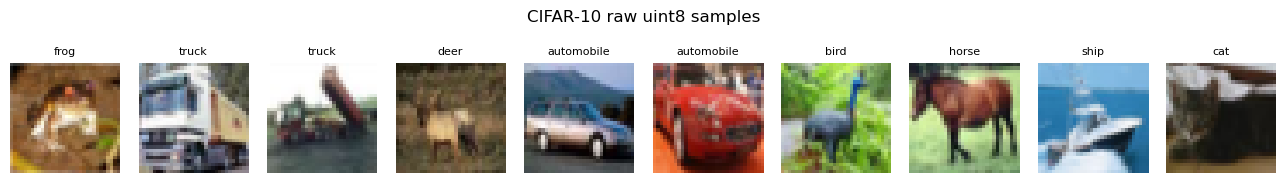

In [2]:
# no transform, so .data stays raw uint8 of shape (N, 32, 32, 3)
cifar_train_raw = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True)
cifar_val_raw   = torchvision.datasets.CIFAR10(root='./data', train=False, download=True)
class_names = cifar_train_raw.classes

print(f'train images: {cifar_train_raw.data.shape}, dtype {cifar_train_raw.data.dtype}')
print(f'val   images: {cifar_val_raw.data.shape}')
print(f'classes: {class_names}')

X_train_raw = cifar_train_raw.data[:200]                 # (200, 32, 32, 3) uint8
y_train_raw = np.array(cifar_train_raw.targets[:200])
X_val_raw   = cifar_val_raw.data[:50]
y_val_raw   = np.array(cifar_val_raw.targets[:50])

fig, axes = plt.subplots(1, 10, figsize=(13, 1.7))
for i in range(10):
    axes[i].imshow(X_train_raw[i])
    axes[i].set_title(class_names[y_train_raw[i]], fontsize=8)
    axes[i].axis('off')
plt.suptitle('CIFAR-10 raw uint8 samples', y=1.05)
plt.tight_layout(); plt.show()

Four operations turn those arrays into batches.

1. `uint8` 0-255 to `float32` 0-1, dividing by 255
2. channel-wise standardization, statistics from the training images only
3. transpose from `(N, H, W, C)` to the `(N, C, H, W)` PyTorch expects
4. `TensorDataset` then `DataLoader`

In [3]:
X_train = X_train_raw.astype(np.float32) / 255.0
X_val   = X_val_raw.astype(np.float32)   / 255.0

# average over the sample and the two spatial axes, leaving one statistic per colour channel
train_mean = X_train.mean(axis=(0, 1, 2))     # (3,)
train_std  = X_train.std(axis=(0, 1, 2))      # (3,)
print(f'train_mean: {train_mean}')
print(f'train_std : {train_std}')

X_train = (X_train - train_mean) / train_std
X_val   = (X_val   - train_mean) / train_std  # statistics from the training set

train_mean: [0.48704952 0.47413558 0.4340601 ]
train_std : [0.24321942 0.23946406 0.25190523]


In [4]:
X_train_tensor = torch.from_numpy(X_train.transpose(0, 3, 1, 2))
X_val_tensor   = torch.from_numpy(X_val.transpose(0, 3, 1, 2))
y_train_tensor = torch.LongTensor(y_train_raw)
y_val_tensor   = torch.LongTensor(y_val_raw)

train_set = TensorDataset(X_train_tensor, y_train_tensor)
val_set   = TensorDataset(X_val_tensor,   y_val_tensor)

train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=8, shuffle=False)

X_batch, Y_batch = next(iter(train_loader))
print(f'batch X: {tuple(X_batch.shape)}  (N, C, H, W), dtype {X_batch.dtype}')
print(f'batch Y: {tuple(Y_batch.shape)}')

batch X: (8, 3, 32, 32)  (N, C, H, W), dtype torch.float32
batch Y: (8,)


In [5]:
print('first sample, channel 0, top-left 4x4 pixels:')
print(X_train_tensor[0, 0, :4, :4].numpy())

first sample, channel 0, top-left 4x4 pixels:
[[-1.0512195  -1.3091967  -1.1963317  -0.90610707]
 [-1.7445335  -2.0025108  -1.7122864  -1.1802081 ]
 [-1.5994213  -1.7445335  -1.2124553  -0.66425335]
 [-1.4704326  -1.3898147  -0.59975904 -0.29341096]]


Those four steps are ten lines of NumPy that have to be repeated for every new image dataset.
And the tensors are now fixed in RAM: every epoch sees exactly the same 200 images, so a random crop
or a flip cannot be applied per epoch.

Both points are answered by the next step.

---
## Step 2. A Custom `Dataset` and `transform`

A `Dataset` is three methods.
`DataLoader` calls `__getitem__` once per sample of every batch, which is where the `transform` runs.

| Method | Returns |
|:---|:---|
| `__init__` | nothing; stores the data and the transform |
| `__len__` | number of samples |
| `__getitem__(index)` | one `(image, label)` pair, transformed |

`transforms.ToTensor` performs operations 1 and 3 of Step 1, `transforms.Normalize` performs operation 2.

In [6]:
class CIFAR10Dataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X                   # numpy uint8, (N, 32, 32, 3)
        self.y = y                   # numpy int, (N,)
        self.transform = transform

    def __len__(self):
        return len(self.y)

    def __getitem__(self, index):
        image = Image.fromarray(self.X[index])   # numpy array to PIL, the input format transforms expect
        if self.transform is not None:
            image = self.transform(image)
        return image, self.y[index]

The same `train_mean` and `train_std` go into `Normalize`, so the numbers below match Step 1 exactly.

`ToTensor` divides by 255 on its own; passing it an already scaled float array would divide twice.

In [7]:
transform_basic = transforms.Compose([
    transforms.ToTensor(),                              # PIL to (C, H, W) float in [0, 1]
    transforms.Normalize(train_mean, train_std),        # channel-wise, same statistics as Step 1
])

train_set = CIFAR10Dataset(X_train_raw, y_train_raw, transform=transform_basic)
val_set   = CIFAR10Dataset(X_val_raw,   y_val_raw,   transform=transform_basic)

train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=8, shuffle=False)

X_batch, Y_batch = next(iter(train_loader))
print(f'batch X: {tuple(X_batch.shape)}  (N, C, H, W), dtype {X_batch.dtype}')
print(f'batch Y: {tuple(Y_batch.shape)}')

print()
print('first sample, channel 0, top-left 4x4 pixels:')
print(train_set[0][0][0, :4, :4].numpy())

batch X: (8, 3, 32, 32)  (N, C, H, W), dtype torch.float32
batch Y: (8,)

first sample, channel 0, top-left 4x4 pixels:
[[-1.0512195  -1.3091967  -1.1963317  -0.90610707]
 [-1.7445335  -2.0025108  -1.7122864  -1.1802081 ]
 [-1.5994213  -1.7445335  -1.2124553  -0.66425335]
 [-1.4704326  -1.3898147  -0.59975904 -0.29341096]]


Read the 4×4 block against the one printed in Step 1 — the two transforms reproduce the ten lines of NumPy.

Everything after this point changes only where `__getitem__` reads from, or what it does to what it read.

Standardized pixels are negative as often as positive, so `imshow` needs them undone first.

In [8]:
# turns a standardized (C, H, W) tensor back into an (H, W, C) array that imshow can display
def unnormalize(image_tensor):
    image = image_tensor.permute(1, 2, 0).numpy()
    image = image * train_std + train_mean
    return np.clip(image, 0, 1)

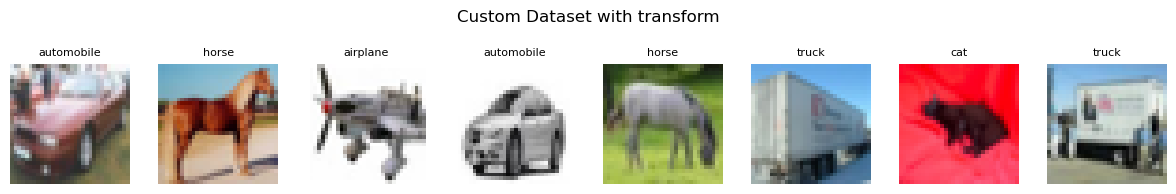

In [9]:
fig, axes = plt.subplots(1, 8, figsize=(12, 1.8))
for i in range(8):
    axes[i].imshow(unnormalize(X_batch[i]))
    axes[i].set_title(class_names[Y_batch[i]], fontsize=8)
    axes[i].axis('off')
plt.suptitle('Custom Dataset with transform', y=1.05)
plt.tight_layout(); plt.show()

---
## Step 3. Reading from Disk — `ImageFolder` and Built-in Datasets

`CIFAR10Dataset` holds every image in RAM, which stops working at a few hundred thousand photographs.
`__getitem__` can read from a file instead, so only the current batch is ever in memory.

| Class | Data lives in | RAM held |
|:---|:---|:---|
| `TensorDataset` | a RAM tensor | the whole dataset |
| `CIFAR10Dataset` | a RAM array | the whole dataset |
| `ImageFolder`, `datasets.CIFAR10` | files on disk | one batch |

The `transform` argument is identical in all three.

### 3.1 `ImageFolder`

`ImageFolder(root, transform)` reads a directory whose subfolder names are the class labels.

```
ROOT/
├── train/  plane/  car/  bird/  cat/  deer/
└── test/   plane/  car/  bird/  cat/  deer/
```

Your own photographs work the same way once they sit in that layout.
The archive below holds 5 classes, 100 train and 50 test images each.

In [10]:
ROOT = './data/cifar5_imagefolder'
URL  = 'https://raw.githubusercontent.com/jongmoonha/Ajou_ME_AI_Undergraduate/main/data/cifar5_imagefolder.zip'

if not os.path.exists(ROOT):
    os.makedirs('./data', exist_ok=True)
    print('downloading cifar5_imagefolder (about 2 MB) ...')
    downloaded_archive = './data/cifar5_imagefolder_download.zip'
    urllib.request.urlretrieve(URL, downloaded_archive)
    with zipfile.ZipFile(downloaded_archive) as archive:
        archive.extractall('./data/')
    os.remove(downloaded_archive)
    print('done.')

for split in ['train', 'test']:
    counts = {name: len(os.listdir(f'{ROOT}/{split}/{name}'))
              for name in sorted(os.listdir(f'{ROOT}/{split}'))}
    print(f'{split}: {counts}')

train: {'bird': 100, 'car': 100, 'cat': 100, 'deer': 100, 'plane': 100}
test: {'bird': 50, 'car': 50, 'cat': 50, 'deer': 50, 'plane': 50}


samples      : 500
classes      : ['bird', 'car', 'cat', 'deer', 'plane']
class to index: {'bird': 0, 'car': 1, 'cat': 2, 'deer': 3, 'plane': 4}


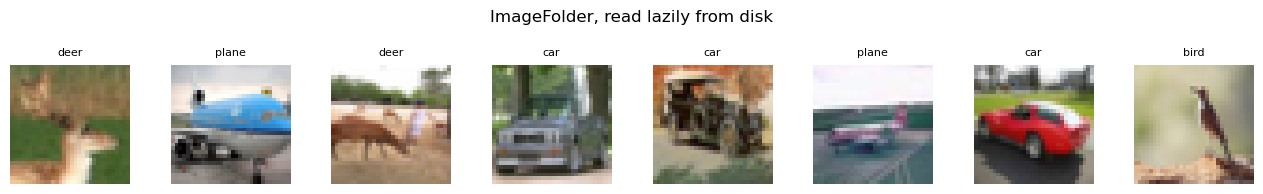

In [11]:
# same transform as Step 2; only the source of the images changed
imagefolder_train = torchvision.datasets.ImageFolder(root=f'{ROOT}/train', transform=transform_basic)

print(f'samples      : {len(imagefolder_train)}')
print(f'classes      : {imagefolder_train.classes}')
print(f'class to index: {imagefolder_train.class_to_idx}')

imagefolder_loader = DataLoader(imagefolder_train, batch_size=8, shuffle=True)
X_batch, Y_batch = next(iter(imagefolder_loader))

fig, axes = plt.subplots(1, 8, figsize=(13, 1.8))
for i in range(8):
    axes[i].imshow(unnormalize(X_batch[i]))
    axes[i].set_title(imagefolder_train.classes[Y_batch[i]], fontsize=8)
    axes[i].axis('off')
plt.suptitle('ImageFolder, read lazily from disk', y=1.05)
plt.tight_layout(); plt.show()

### 3.2 Built-in Datasets

`datasets.CIFAR10`, `datasets.MNIST` and the rest take the same `transform` argument, with no class to write.

For a benchmark this well known the channel statistics are published, computed over all 50000 training
images, so they replace the ones measured from 200 images above.

In [12]:
# published CIFAR-10 statistics, computed over the 50000 training images
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2440, 0.2620)

transform_cifar_standard = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

cifar_train = torchvision.datasets.CIFAR10(
    root='./data', train=True,  download=True, transform=transform_cifar_standard)
cifar_val = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_cifar_standard)

cifar_loader = DataLoader(cifar_train, batch_size=8, shuffle=True)
X_batch, Y_batch = next(iter(cifar_loader))

print(f'train: {len(cifar_train)} samples, val: {len(cifar_val)} samples')
print(f'batch X: {tuple(X_batch.shape)}, batch Y: {tuple(Y_batch.shape)}')

train: 50000 samples, val: 10000 samples
batch X: (8, 3, 32, 32), batch Y: (8,)


---
## Step 4. Augmentation — A New View Every Call

`ToTensor` and `Normalize` are deterministic, so the same index always gives the same tensor.
Random transforms are not, and `__getitem__` runs once per epoch per sample.
The model therefore never sees the identical training set twice, which is what suppresses overfitting.

| Transform | Effect |
|:---|:---|
| `RandomCrop(32, padding=4)` | pads with zeros, then cuts a 32×32 window at a random offset |
| `RandomHorizontalFlip(p=0.5)` | mirrors left to right half the time |

Augmentation belongs to training only; evaluation has to be deterministic.

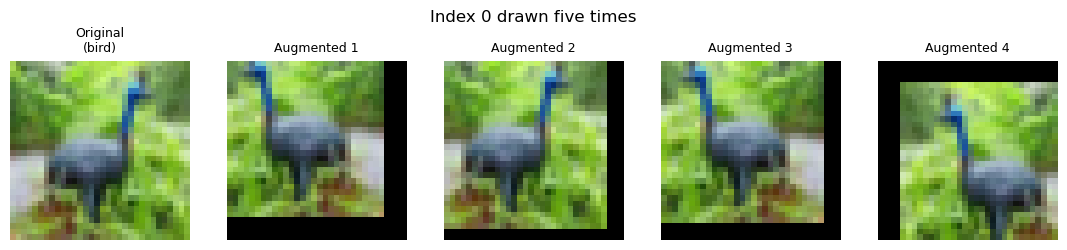

In [13]:
transform_augmented = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(train_mean, train_std),
])

# same files, same Dataset class as Step 3, only the transform differs
imagefolder_train_augmented = torchvision.datasets.ImageFolder(
    root=f'{ROOT}/train', transform=transform_augmented)

torch.manual_seed(0)
image_plain, label_plain = imagefolder_train[0]          # deterministic transform

fig, axes = plt.subplots(1, 5, figsize=(11, 2.5))
axes[0].imshow(unnormalize(image_plain))
axes[0].set_title(f'Original\n({imagefolder_train.classes[label_plain]})', fontsize=9)
axes[0].axis('off')
for i in range(4):
    image_augmented, _ = imagefolder_train_augmented[0]  # index 0 again, a new random view each time
    axes[i + 1].imshow(unnormalize(image_augmented))
    axes[i + 1].set_title(f'Augmented {i + 1}', fontsize=9)
    axes[i + 1].axis('off')
plt.suptitle('Index 0 drawn five times')
plt.tight_layout(); plt.show()

A `DataLoader` built on that dataset inherits the behaviour, since it fills its batches through the same
`__getitem__`.

Shuffling is switched off below so that both calls return the same images, leaving the augmentation as
the only difference on screen.

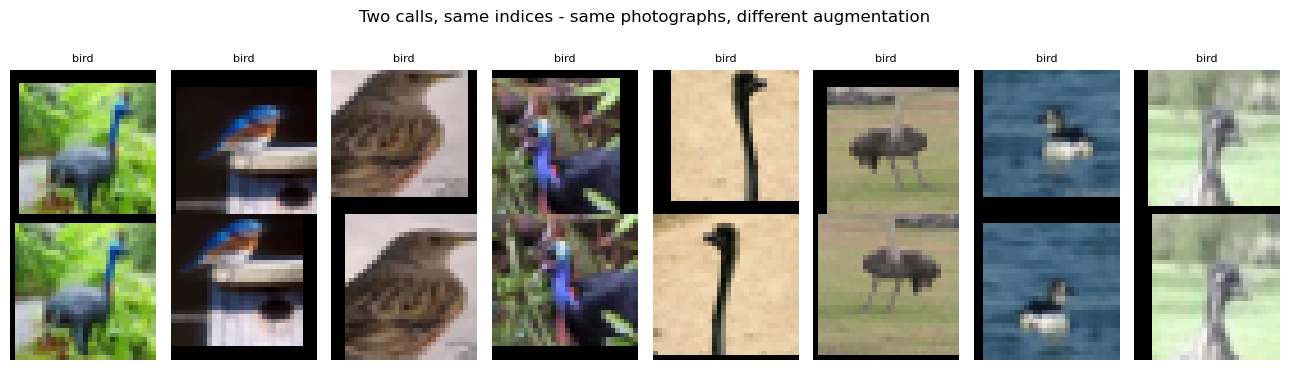

In [14]:
augmented_loader = DataLoader(imagefolder_train_augmented, batch_size=8, shuffle=False)

X_batch_first,  Y_batch_first  = next(iter(augmented_loader))
X_batch_second, Y_batch_second = next(iter(augmented_loader))

fig, axes = plt.subplots(2, 8, figsize=(13, 3.6))
for i in range(8):
    axes[0, i].imshow(unnormalize(X_batch_first[i]))
    axes[0, i].set_title(imagefolder_train.classes[Y_batch_first[i]], fontsize=8)
    axes[0, i].axis('off')
    axes[1, i].imshow(unnormalize(X_batch_second[i]))
    axes[1, i].axis('off')
plt.suptitle('Two calls, same indices - same photographs, different augmentation', y=1.02)
plt.tight_layout(); plt.show()

---
## Step 5. The Pair of Loaders a Training Run Needs

Training and evaluation differ in the transform, not in the dataset class.

| Split | Transform | Shuffle |
|:---|:---|:---|
| train | random crop, flip, `ToTensor`, `Normalize` | yes |
| val, test | `ToTensor`, `Normalize` | no |

In [15]:
train_set_final = torchvision.datasets.ImageFolder(root=f'{ROOT}/train', transform=transform_augmented)
val_set_final   = torchvision.datasets.ImageFolder(root=f'{ROOT}/test',  transform=transform_basic)

train_loader_final = DataLoader(train_set_final, batch_size=8, shuffle=True)
val_loader_final   = DataLoader(val_set_final,   batch_size=8, shuffle=False)

X_batch, Y_batch = next(iter(train_loader_final))
print(f'train batch: {tuple(X_batch.shape)}, augmented')
X_batch, Y_batch = next(iter(val_loader_final))
print(f'val   batch: {tuple(X_batch.shape)}, not augmented')

train batch: (8, 3, 32, 32), augmented
val   batch: (8, 3, 32, 32), not augmented


---
## Summary

- A `Dataset` is `__len__` and `__getitem__`; every class here differs only in what `__getitem__` reads.
- `ToTensor` and `Normalize` replace the scaling, standardization and transpose written by hand in Step 1.
- Random transforms make `__getitem__` return a new view per epoch, which is why augmentation costs no
  extra storage and must be kept off the evaluation loaders.

---
## Exercises

1. Print `train_mean` and `train_std` measured on all 50000 CIFAR-10 training images.
   How far are they from the values measured on 200?
2. Give `val_loader_final` the augmented transform and draw one batch twice.
   Why would that make a validation accuracy hard to read?
3. Add `transforms.RandomRotation(15)` to `transform_augmented` and redraw index 0 four times.
4. Point `ImageFolder` at a folder of your own photographs, one subfolder per class, and draw a batch.

In [16]:
# Write your code here